First rows of dataset:
             timestamp           src_ip           dst_ip  src_port  dst_port  \
0  2025-10-01 00:12:54   188.176.27.165  253.240.113.218     56377       445   
1  2025-10-01 00:23:43      68.59.26.43    212.75.38.111     51165      1433   
2  2025-10-01 00:25:46   119.204.243.78     90.28.90.234     14948      1433   
3  2025-10-01 00:27:21  122.119.194.175   175.140.78.230     36097       443   
4  2025-10-01 00:40:09   181.199.242.68     55.99.177.69       445     21255   

  protocol  bytes_sent  bytes_received  \
0      TCP        8029           17204   
1      TCP      676368         2643374   
2      TCP      316502           38571   
3      TCP       70933           21935   
4      TCP       12721            9939   

                                          user_agent  \
0  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
3  Mozilla/5.0 (Win

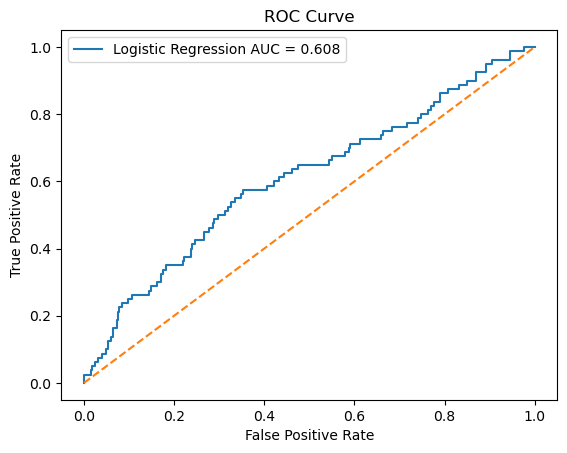

In [11]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# ================================
# 2. Load Dataset
# ================================
# New network anomaly dataset
df = pd.read_csv("networkanomalydataset.csv")

print("First rows of dataset:")
print(df.head())

print("\nDataset info:")
print(df.info())


# Expected columns:
#   - Inbound Rate(bit/s)
#   - Outbound Rate(bit/s)
#   - Inbound Bandwidth Utilization(%)
#   - Outbound Bandwidth Utilization(%)
#   - Label (0 = normal, 1 = anomaly)


# ================================
# 3. Basic Checks
# ================================
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["Label"].value_counts(normalize=True))


# ================================
# 4. Define Features and Target
# ================================
X = df.drop("Label", axis=1)
# All feature columns are numeric in this dataset
feature_names = X.columns.tolist()

# Ensure numeric dtype
X = X.astype(float)

y = df["Label"].astype(int)


# ================================
# 5. Train-Test Split (Stratified)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


# ================================
# 6. Scaling + Logistic Regression Pipeline
# ================================
model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                max_iter=10000,
                class_weight="balanced",  # handle potential imbalance
                solver="lbfgs",
            ),
        ),
    ]
)

# Fit model
model.fit(X_train, y_train)


# ================================
# 7. Predictions
# ================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# ================================
# 8. Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ================================
# 9. Classification Report
# ================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ================================
# 10. ROC Curve and AUC
# ================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression AUC = " + str(round(auc, 3)))
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()